In the preivous lab session, we have learned the privacy and security issues in machine learning, deep learning and federated learning. In this lab session, we involve a hot privacy research topic in machine learning, machine unlearning, i.e., removing the trace of specified samples from an already-trained model. We investigate how to implement the data removal of a ML model.




**Objectives**

1. Review how to train a simple machine learning model using Pytorch
2. Implement the Hessian matrix-based machine unlearning based on the already-trained model



# Preparation
## Objevtive 1: Train a simple machine learning model using Pytorch
### Preparation packages

In [ ]:
import sys

sys.argv = ['']
del sys

import math
from collections import defaultdict
import argparse
from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.optim
from torchvision.utils import save_image
import torchvision
from torchvision.datasets import MNIST, CIFAR10, FashionMNIST
from torch.utils.data import DataLoader, TensorDataset, random_split, ConcatDataset, Subset, Dataset
import torch.utils.data as Data
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

import copy
import random
import time

### Create a simple neural network class

In [ ]:

class LinearModel(nn.Module):
    # 定义神经网络
    def __init__(self, n_feature=192, h_dim=3 * 32, n_output=10):
        # 初始化数组，参数分别是初始化信息，特征数，隐藏单元数，输出单元数
        super(LinearModel, self).__init__()
        self.fc1 = nn.Linear(n_feature, h_dim)  # 第一个全连接层
        self.fc2 = nn.Linear(h_dim, n_output)  # output

    # 设置隐藏层到输出层的函数

    def forward(self, x):
        # 定义向前传播函数
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
def args_parser():
    parser = argparse.ArgumentParser(description='Process some integers.')
    parser.add_argument('--dataset', choices=['MNIST', 'CIFAR10'], default='MNIST')
    parser.add_argument('--cuda', action='store_true')
    parser.add_argument('--num_epochs', type=int, default=10, help='Number of training epochs for VIBI.')
    parser.add_argument('--explainer_type', choices=['Unet', 'ResNet_2x', 'ResNet_4x', 'ResNet_8x'],
                        default='ResNet_4x')
    parser.add_argument('--xpl_channels', type=int, choices=[1, 3], default=1)
    parser.add_argument('--k', type=int, default=12, help='Number of chunks.')
    parser.add_argument('--beta', type=float, default=0, help='beta in objective J = I(y,t) - beta * I(x,t).')
    parser.add_argument('--unlearning_ratio', type=float, default=0.1)
    parser.add_argument('--num_samples', type=int, default=4,
                        help='Number of samples used for estimating expectation over p(t|x).')
    parser.add_argument('--resume_training', action='store_true')
    parser.add_argument('--save_best', action='store_true',
                        help='Save only the best models (measured in valid accuracy).')
    parser.add_argument('--save_images_every_epoch', action='store_true', help='Save explanation images every epoch.')
    parser.add_argument('--jump_start', action='store_true', default=False)
    args = parser.parse_args()
    return args

### Parameters preparation

In [ ]:
seed = 0
torch.cuda.manual_seed_all(seed)
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# torch.use_deterministic_algorithms(True)

# parse args
args = args_parser()
args.gpu = -1
# args.num_users = 10
args.device = torch.device('cuda:{}'.format(args.gpu) if torch.cuda.is_available() and args.gpu != -1 else 'cpu')
args.iid = True
args.model = 'z_linear'
args.num_epochs = 1
args.dataset = 'MNIST'
args.add_noise = False
args.beta = 0.0001
args.mse_rate = 10
args.lr = 0.0001
args.dimZ = 20 #40 #2
args.batch_size = 16
args.erased_local_r = 0.002 # the erased data ratio
args.train_type = "MULTI"
args.kld_to_org = 1
args.unlearn_bce = 0.3
args.self_sharing_rate = 1
args.hessian_rate = 0.0005

### Load the MNIST dataset

In [ ]:

# print('args.beta', args.beta, 'args.lr', args.lr)

print('\n'.join(f'{k}={v}' for k, v in vars(args).items()))

device = args.device
print("device", device)

if args.dataset == 'MNIST':
    transform = T.Compose([
        T.ToTensor()
        # transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    trans_mnist = transforms.Compose([transforms.ToTensor(), ])
    train_set = MNIST('data/mnist', train=True, transform=trans_mnist, download=True)
    test_set = MNIST('data/mnist', train=False, transform=trans_mnist, download=True)
    train_set_no_aug = train_set

dataset=MNIST
cuda=False
num_epochs=1
explainer_type=ResNet_4x
xpl_channels=1
k=12
beta=0.0001
unlearning_ratio=0.1
num_samples=4
resume_training=False
save_best=False
save_images_every_epoch=False
jump_start=False
gpu=-1
device=cpu
iid=True
model=z_linear
add_noise=False
mse_rate=10
lr=0.0001
dimZ=20
batch_size=16
erased_local_r=0.002
train_type=MULTI
kld_to_org=1
unlearn_bce=0.3
self_sharing_rate=1
hessian_rate=0.0005
device cpu


### Training data with backdoor preparation

In [ ]:
def add_trigger_new(add_backdoor, dataset, poison_samples, mode, feature_extra):
    print("## generate——test " + mode + " Bad Imgs")

    # indices = dataset.indices
    list_from_dataset_tuple = list(dataset)
    indices = list(range(len(list_from_dataset_tuple)))
    new_data_re = []

    x, y = list_from_dataset_tuple[0]

    # total_poison_num = int(len(new_data) * portion/10)
    _, width, height = x.shape

    for i in range(len(list_from_dataset_tuple)):
        if add_backdoor == 1:

            x, y = list_from_dataset_tuple[i]
            # x = generate_gray_laplace_small_trigger_noise(x) #generate_gray_laplace_small_trigger_noise(x)
            # new_data[i] = image_steg

            # Plotting
            # plt.imshow(embedded_image)
            # plt.title("Image with Embedded Feature Map")
            # plt.axis('off')
            # plt.show()

            # add trigger as general backdoor
            x[:, width - 3, height - 3] = 1
            x[:, width - 3, height - 4] = 1
            x[:, width - 4, height - 3] = 1
            x[:, width - 4, height - 4] = 1

            list_from_dataset_tuple[i] = x, 7 # 7 is the changed label
            # new_data[i, :, width - 23, height - 21] = 254
            # new_data[i, :, width - 23, height - 22] = 254
            # new_data[i, :, width - 22, height - 21] = 254
            # new_data[i, :, width - 24, height - 21] = 254
            # new_data[i] = torch.from_numpy(embedded_image).view([1,28,28])
            #      new_data_re.append(embedded_image)
            poison_samples = poison_samples - 1
            if poison_samples <= 0:
                break
        # x=torch.tensor(new_data[i])
        # x_cpu = x.cpu().data
        # x_cpu = x_cpu.clamp(0, 1)
        # x_cpu = x_cpu.view(1, 1, 28, 28)
        # grid = torchvision.utils.make_grid(x_cpu, nrow=1, cmap="gray")
        # plt.imshow(np.transpose(grid, (1, 2, 0)))  # 交换维度，从GBR换成RGB
        # plt.show()

    # print(len(new_data_re))
    return Subset(list_from_dataset_tuple, indices)

59880
60000
## generate——test train Bad Imgs
tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

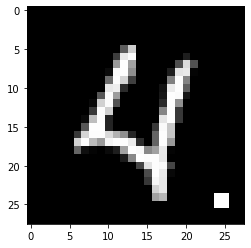

In [ ]:

train_loader = DataLoader(train_set, batch_size=args.batch_size, shuffle=True, num_workers=1)
test_loader = DataLoader(test_set, batch_size=args.batch_size, shuffle=False, num_workers=1)

full_size = len(train_set)

erasing_size = int(full_size * args.erased_local_r)
remaining_size = full_size - erasing_size

remaining_set, erasing_set = torch.utils.data.random_split(train_set, [remaining_size, erasing_size])

print(len(remaining_set))
print(len(remaining_set.dataset.data))

# remaining_subset = My_subset(remaining_set.dataset, remaining_set.indices)
# erasing_subset = My_subset(erasing_set.dataset, erasing_set.indices)

dataloader_remain = DataLoader(remaining_set, batch_size=args.batch_size, shuffle=True)

# if we don't use poisoned set, we use full set
dataloader_erased = DataLoader(erasing_set, batch_size=args.batch_size, shuffle=True)

# Assuming train_loader1 and train_loader2 are your data loaders
dataset1 = dataloader_remain.dataset
dataset2 = dataloader_erased.dataset

# Concatenate datasets and create a new loader
combined_dataset = ConcatDataset([dataset1, dataset2])
combined_loader = DataLoader(combined_dataset, batch_size=args.batch_size, shuffle=True)



########################################################################
## add trigger


## add to one class

add_backdoor = 1  # =1 add backdoor , !=1 not add
# reshaped_data = data_reshape_to_np(erasing_subset, dataname=args.dataset)
poison_samples = erasing_size # len(erasing_subset.data)
mode = "train"


erased_set_with_tri = add_trigger_new(add_backdoor, dataset2, poison_samples, mode, None)

poison_samples = int(full_size) * args.erased_local_r

x, y = erased_set_with_tri[1]

# print(x)
x = x.cpu().data
x = x.clamp(0, 1)
if args.dataset == "MNIST":
    x = x.view(x.size(0), 1, 28, 28)
elif args.dataset == "CIFAR10":
    x = x.view(1, 3, 32, 32)
print(x)
grid = torchvision.utils.make_grid(x, nrow=1, cmap="gray")
plt.imshow(np.transpose(grid, (1, 2, 0)))  # 交换维度，从GBR换成RGB
plt.show()



# Concatenate datasets and create a new loader
poison_trainset = ConcatDataset([dataset1, erased_set_with_tri])


dataloader_remain = DataLoader(dataset1, batch_size=args.batch_size, shuffle=True)

# if we don't use poisoned set, we use full set
dataloader_full = DataLoader(poison_trainset, batch_size=args.batch_size, shuffle=True)


### Model initialization

In [ ]:
def init_model(args):
    model = LinearModel(n_feature=28 * 28, n_output=10)
    model.to(args.device)
    return model, args.lr

In [ ]:

lnn, lr = init_model(args)
lnn.to(args.device)

loss_fn = nn.CrossEntropyLoss()

reconstruction_function = nn.MSELoss(size_average=True)

acc_test = []
print("learning")

print('Training lnn')

# inspect_explanations()


# train VIB
mu_list = []
sigma_list = []

train_type = args.train_type



learning
Training lnn


/Users/wwq/opt/anaconda3/envs/Share_improve/lib/python3.7/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  warnings.warn(warning.format(ret))


### Model training

In [ ]:
def lnn_train(dataset, model, loss_fn, reconstruction_function, args, epoch, mu_list, sigma_list, train_loader, train_type):
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)

    for step, (x, y) in enumerate(dataset):
        x, y = x.to(args.device), y.to(args.device)  # (B, C, H, W), (B, 10)
        x = x.view(x.size(0), -1)

        logits_y = model(x)  # (B, C* h* w), (B, N, 10)
        # VAE two loss: KLD + MSE

        H_p_q = loss_fn(logits_y, y)

 #lnn

        loss = H_p_q


        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5, norm_type=2.0, error_if_nonfinite=False)
        optimizer.step()


        metrics = {
            # 'acc': acc,
            'loss': loss.item()
        }

        if step % len(train_loader) % 10000 == 0:
            print(f'[{epoch}/{0 + args.num_epochs}:{step % len(train_loader):3d}] '
                  + ', '.join([f'{k} {v:.3f}' for k, v in metrics.items()]))

    return model, mu_list, sigma_list

In [ ]:
start_time = time.time()
for epoch in range(args.num_epochs):
    lnn.train()
    lnn, mu_list, sigma_list = lnn_train(dataloader_full, lnn, loss_fn, reconstruction_function, args, epoch, mu_list,
                                         sigma_list, train_loader, train_type)

print('mu', np.mean(mu_list), 'sigma', np.mean(sigma_list))

end_time = time.time()

running_time = end_time - start_time
print(f'VIB Training took {running_time} seconds')

[0/1:  0] loss 2.343
mu nan sigma nan
VIB Training took 13.523291826248169 seconds


/Users/wwq/opt/anaconda3/envs/Share_improve/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/Users/wwq/opt/anaconda3/envs/Share_improve/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


## Hessian Unlearning


### 1. **Objective**  
The goal of machine unlearning is to adjust a trained model $\theta_{\text{train}}$ after the removal of an erasing data point $x_e$ from the training set, to produce a new model $\theta_{\text{unl.}}$, such that the influence of $x_e$ is removed without retraining the model from scratch.

### 2. **Hessian Matrix Definition**  
Let the loss function be denoted as $L(\theta)$, where $\theta$ represents the model parameters. The gradient of the loss with respect to the parameters is:
$$
\nabla_{\theta} L(\theta) = \frac{\partial L}{\partial \theta}
$$
The Hessian matrix $H$ is the matrix of second-order partial derivatives of the loss function:
$$
H(\theta) = \nabla_{\theta}^2 L(\theta) = \frac{\partial^2 L}{\partial \theta^2}
$$
It describes the curvature of the loss landscape around $\theta$.

### 3. **Update Rule for Unlearning**

Given that $x_e$ is the data point to be removed, the goal is to update the model parameters $\theta_{\text{train}}$ to reflect the removal of $x_e$. This can be done using an approximation based on the gradient and Hessian.

Let $\nabla L(x_e, \theta)$ be the gradient of the loss function evaluated at the removed data point $x_e$. The parameter update after removing $x_e$ can be approximated using a second-order Taylor expansion:

$$
\theta_{\text{unlearned}} \approx \theta_{\text{train}} - H(\theta_{\text{train}})^{-1} \nabla L(x_e, \theta_{\text{train}})
$$

Where:
- $\nabla \mathcal{L}(x_e, \theta_{\text{train}})$ is the gradient of the loss with respect to the model parameters due to the data point $x_e$,
- $H(\theta_{\text{train}})$ is the Hessian matrix evaluated at the current parameters $ \theta_{\text{train}}$,
- $H(\theta_{\text{train}})^{-1}$ represents the inverse of the Hessian, which provides the curvature information needed for the update.

### 4. **First-Order Approximation**
In practice, computing the full Hessian and its inverse can be computationally expensive. As a result, a first-order approximation may be used, known as the **Newton step** or a quasi-Newton approximation. This updates the parameters using the gradient only:
$$
\theta_{\text{unlearned}} \approx \theta_{\text{train}} - \eta \nabla L(x_e, \theta_{\text{train}})
$$
Where $\eta$ is a learning rate or step size, and this approach is computationally simpler but may result in less precise unlearning.

### 5. **Unlearning Criterion**
The success of unlearning can be measured by the difference in the loss function before and after unlearning. The aim is for the loss function after removing $x_e$ to resemble the loss function as if $x_e$ had never been included in the training data:

$$
L_{\text{unlearned}}(\theta_{\text{unl.}}) \approx L_{\text{train} - x_e}(\theta_{\text{ideal}})
$$

Where $L_{\text{train} - x_e}$ is the loss function after retraining without $x_e$, and $\theta_{\text{ideal}}$ is the ideal parameter configuration after retraining.



In [ ]:
class AdaHessian(torch.optim.Optimizer):
    """
    Implements the AdaHessian algorithm from "ADAHESSIAN: An Adaptive Second OrderOptimizer for Machine Learning"

    Arguments:
        params (iterable) -- iterable of parameters to optimize or dicts defining parameter groups
        lr (float, optional) -- learning rate (default: 0.1)
        betas ((float, float), optional) -- coefficients used for computing running averages of gradient and the squared hessian trace (default: (0.9, 0.999))
        eps (float, optional) -- term added to the denominator to improve numerical stability (default: 1e-8)
        weight_decay (float, optional) -- weight decay (L2 penalty) (default: 0.0)
        hessian_power (float, optional) -- exponent of the hessian trace (default: 1.0)
        update_each (int, optional) -- compute the hessian trace approximation only after *this* number of steps (to save time) (default: 1)
        n_samples (int, optional) -- how many times to sample `z` for the approximation of the hessian trace (default: 1)
    """

    def __init__(self, params, lr=0.1, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.0,
                 hessian_power=1.0, update_each=1, n_samples=1, average_conv_kernel=False):
        if not 0.0 <= lr:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= eps:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 1: {betas[1]}")
        if not 0.0 <= hessian_power <= 1.0:
            raise ValueError(f"Invalid Hessian power value: {hessian_power}")

        self.n_samples = n_samples
        self.update_each = update_each
        self.average_conv_kernel = average_conv_kernel

        # use a separate generator that deterministically generates the same `z`s across all GPUs in case of distributed training
        self.generator = torch.Generator().manual_seed(2147483647)

        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay, hessian_power=hessian_power)
        super(AdaHessian, self).__init__(params, defaults)

        for p in self.get_params():
            p.requires_grad = True
            p.hess = 0.0
            self.state[p]["hessian step"] = 0

    def get_params(self):
        """
        Gets all parameters in all param_groups with gradients
        """

        return (p for group in self.param_groups for p in group['params'] if p.requires_grad)

    def zero_hessian(self):
        """
        Zeros out the accumalated hessian traces.
        """

        for p in self.get_params():
            if not isinstance(p.hess, float) and self.state[p]["hessian step"] % self.update_each == 0:
                p.hess.zero_()

    @torch.no_grad()
    def set_hessian(self):
        """
        Computes the Hutchinson approximation of the hessian trace and accumulates it for each trainable parameter.
        """

        params = []
        for p in filter(lambda p: p.grad is not None, self.get_params()):
            if self.state[p]["hessian step"] % self.update_each == 0:  # compute the trace only each `update_each` step
                params.append(p)
            self.state[p]["hessian step"] += 1

        if len(params) == 0:
            return

        if self.generator.device != params[0].device:  # hackish way of casting the generator to the right device
            self.generator = torch.Generator(params[0].device).manual_seed(2147483647)

        # for p in params:
        #     # p.grad.requires_grad=True
        #     print(p.shape)
        #     print(p.grad.shape)
        grads = [p.grad for p in params]
        # grads.requires_grad = True
        # print("grads", grads)

        for i in range(self.n_samples):
            zs = [torch.randint(0, 2, p.size(), generator=self.generator, device=p.device) * 2.0 - 1.0 for p in params]  # Rademacher distribution {-1.0, 1.0}

            h_zs = torch.autograd.grad(grads, params, grad_outputs=zs, only_inputs=True, retain_graph=i < self.n_samples - 1)
            for h_z, z, p in zip(h_zs, zs, params):
                # print(h_z, z)
                p.hess += h_z * z / self.n_samples  # approximate the expected values of z*(H@z)
                # print("p.hess", p.hess.shape)

    @torch.no_grad()
    def step(self, closure=None):
        """
        Performs a single optimization step.
        Arguments:
            closure (callable, optional) -- a closure that reevaluates the model and returns the loss (default: None)
        """

        loss = None
        if closure is not None:
            loss = closure()

        self.zero_hessian()
        self.set_hessian()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or p.hess is None:
                    continue

                if self.average_conv_kernel and p.dim() == 4:
                    p.hess = torch.abs(p.hess).mean(dim=[2, 3], keepdim=True).expand_as(p.hess).clone()

                # Perform correct stepweight decay as in AdamW
                p.mul_(1 - group['lr'] * group['weight_decay'])

                state = self.state[p]

                # State initialization
                if len(state) == 1:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)  # Exponential moving average of gradient values
                    state['exp_hessian_diag_sq'] = torch.zeros_like(p.data)  # Exponential moving average of Hessian diagonal square values

                exp_avg, exp_hessian_diag_sq = state['exp_avg'], state['exp_hessian_diag_sq']
                beta1, beta2 = group['betas']
                state['step'] += 1

                # Decay the first and second moment running average coefficient
                exp_avg.mul_(beta1).add_(p.grad, alpha=1 - beta1)
                exp_hessian_diag_sq.mul_(beta2).addcmul_(p.hess, p.hess, value=1 - beta2)

                bias_correction1 = 1 - beta1 ** state['step']
                bias_correction2 = 1 - beta2 ** state['step']

                k = group['hessian_power']
                denom = (exp_hessian_diag_sq / bias_correction2).pow_(k / 2).add_(group['eps'])

                # make update
                step_size = group['lr'] / bias_correction1
                #p.addcdiv_(exp_avg, denom, value=-step_size)
                p = p.addcdiv_(exp_avg, denom, value=step_size)

        return self.get_params()


    @staticmethod
    @torch.no_grad()
    def hessian_unl_update(p, hess, args, i):
        average_conv_kernel = False
        weight_decay = 0.0
        betas = (0.9, 0.999)
        hessian_power = 1.0
        eps = args.lr # 1e-8

        if average_conv_kernel and p.dim() == 4:
            hess = torch.abs(hess).mean(dim=[2, 3], keepdim=True).expand_as(hess).clone()

        # Perform correct stepweight decay as in AdamW
        # p = p.mul_(1 - args.lr * weight_decay)

        state = {}
        state["hessian"] = 1

        # State initialization
        if len(state) == 1:
            state['step'] = 0
            state['exp_avg'] = torch.zeros_like(p.data)  # Exponential moving average of gradient values
            state['exp_hessian_diag_sq'] = torch.zeros_like(
                p.data)  # Exponential moving average of Hessian diagonal square values

        exp_avg, exp_hessian_diag_sq = state['exp_avg'], state['exp_hessian_diag_sq']
        beta1, beta2 = betas
        state['step'] = i

        # Decay the first and second moment running average coefficient

        exp_avg.mul_(beta1).add_(p.grad, alpha=1 - beta1)
        #exp_hessian_diag_sq.mul_(beta2).addcmul_(p_hs.hess, p_hs.hess, value=1 - beta2)
        exp_hessian_diag_sq.mul_(beta2).addcmul_(hess, hess, value=1 - beta2)

        bias_correction1 = 1 #- beta1 ** state['step']
        bias_correction2 = 1 #- beta2 ** state['step']

        k = hessian_power
        denom = (exp_hessian_diag_sq / bias_correction2).pow_(k / 2).add_(eps)

        # make update
        step_size = args.lr / bias_correction1
        # p.addcdiv_(exp_avg, denom, value=-step_size)
        p = p.addcdiv_(exp_avg, denom, value=step_size * 0.1)
        #p_hs.data = p_hs.data + args.lr * p_hs.grad.data * 10
        return exp_avg, denom, step_size

In [ ]:
def calculate_hs_p(H_p_q2, optimizer_hessian, lnn_f_hessian):
    loss = H_p_q2  # + BCE / (args.local_bs * 28 * 28)
    optimizer_hessian.zero_grad()

    # loss.backward()
    # log_probs = net(images)
    # loss = self.loss_func(log_probs, labels)

    loss.backward(create_graph=True)

    optimizer_hs = AdaHessian(lnn_f_hessian.parameters())
    # optimizer_hs.get_params()
    optimizer_hs.zero_hessian()
    optimizer_hs.set_hessian()

    params_with_hs = optimizer_hs.get_params()
    # optimizer_hessian.step()
    optimizer_hessian.zero_grad()
    lnn_f_hessian.zero_grad()

    return params_with_hs

In [ ]:

@torch.no_grad()
def test_accuracy(model, data_loader, args, name='test'):
    num_total = 0
    num_correct = 0
    model.eval()
    for x, y in data_loader:
        x, y = x.to(args.device), y.to(args.device)
        x = x.view(x.size(0), -1)
        out = model(x)
        if y.ndim == 2:
            y = y.argmax(dim=1)
        num_correct += (out.argmax(dim=1) == y).sum().item()
        num_total += len(x)
    acc = num_correct / num_total
    acc = round(acc, 5)
    print(f'{name} accuracy: {acc:.4f}')
    return acc


In [ ]:

def unlearning_hessian_train(lnn, dataloader_erase, remaining_set, loss_fn,test_loader, train_loader ):
    lnn_f_hessian, lr = init_model(args)
    lnn_f_hessian.to(args.device)
    lnn_f_hessian.load_state_dict(lnn.state_dict())
    optimizer_hessian = torch.optim.Adam(lnn_f_hessian.parameters(), lr=lr)

    init_epoch = 0
    print("unlearning")
    epoch_loss = []
    acc_list = []
    acc_test = []
    backdoor_acc_list = []
    params_with_hs = None

    logs = defaultdict(list)

    reconstructor_for_unlearning = LinearModel(n_feature=49, n_output=28 * 28)
    reconstructor_for_unlearning = reconstructor_for_unlearning.to(args.device)
    optimizer_recon_for_un = torch.optim.Adam(reconstructor_for_unlearning.parameters(), lr=lr)

    dataloader_remain = DataLoader(remaining_set, batch_size=remaining_set.__len__(), shuffle=True)
    dataloader_remain2 = DataLoader(remaining_set, batch_size=args.batch_size, shuffle=True)

    train_bs = 0
    # prepare hessian
    index = 0
    for batch_idx, (images, labels) in enumerate(dataloader_remain):
        images, labels = images.to(args.device), labels.to(args.device)
        B, c, h, w = images.shape
        # print(B,h,w)

        images = images.reshape((B, -1))
        lnn_f_hessian.zero_grad()
        print('batch_idx', batch_idx)
        logits_y = lnn_f_hessian(images)  # (B, C* h* w), (B, N, 10)
        H_p_q = loss_fn(logits_y, labels)

        loss = H_p_q  # + BCE / (args.local_bs * 28 * 28)
        optimizer_hessian.zero_grad()

        # loss.backward()
        # log_probs = net(images)
        # loss = self.loss_func(log_probs, labels)

        loss.backward(create_graph=True)

        optimizer_hs = AdaHessian(lnn_f_hessian.parameters())
        # optimizer_hs.get_params()
        optimizer_hs.zero_hessian()
        optimizer_hs.set_hessian()

        params_with_hs = optimizer_hs.get_params()

        optimizer_hessian.zero_grad()
        lnn_f_hessian.zero_grad()

    if init_epoch == 0 or args.resume_training:

        print('Unlearning VIBI KLD')

        epoch_test_acc = []
        mu_list = []
        sigma_list = []

        # unlearning
        convergence = 0
        temp_acc = []
        temp_back = []

        for iter in range(args.num_epochs):  # self.args.local_ep
            batch_loss = []
            # print(iter)

            for (images, labels), (images2, labels2) in zip(dataloader_erase, dataloader_remain2):
                # for batch_idx, (images, labels) in enumerate(self.erased_loader):
                images, labels = images.to(args.device), labels.to(args.device)
                B, c, h, w = images.shape
                # print(B,h,w)

                images = images.reshape((B, -1))

                images2, labels2 = images2.to(args.device), labels2.to(args.device)
                B, c, h, w = images2.shape

                images2 = images2.reshape((B, -1))

                lnn_f_hessian.zero_grad()
                logits_y = lnn_f_hessian(images)  # (B, C* h* w), (B, N, 10)
                logits_y2 = lnn_f_hessian(images2)

                ##remaining dataset used to unlearn

                H_p_q = loss_fn(logits_y, labels)


                H_p_q2 = loss_fn(logits_y2, labels2)

                params_with_hs = calculate_hs_p(H_p_q2, optimizer_hessian, lnn_f_hessian)



                loss = H_p_q  # + BCE / (args.local_bs * 28 * 28)
                optimizer_hessian.zero_grad()

                loss.backward()
                # log_probs = net(images)
                # loss = self.loss_func(log_probs, labels)

                i = 0
                for p_hs, p in zip(params_with_hs, lnn_f_hessian.parameters()):
                    i = i + 1
                    # if i==1:
                    #     continue
                    # print(p_hs.hess)
                    # break
                    temp_hs = torch.tensor(p_hs.hess)
                    # temp_hs = temp_hs.__add__(args.lr)
                    # p.data = p.data.addcdiv_(exp_avg, denom, value=-step_size * 10000)

                    # print(p.data)
                    # p.data = p_hs.data.addcdiv_(exp_avg, denom, value=step_size * args.lr)
                    if p.grad != None:
                        exp_avg, denom, step_size = AdaHessian.hessian_unl_update(p, temp_hs, args, i)
                        # print(exp_avg)
                        # print(denom)
                        p.data = p.data.addcdiv_(exp_avg, denom, value=args.hessian_rate)
                        # p.data =p.data + torch.div(p.grad.data, temp_hs) * args.lr #torch.mul(p_hs.hess, p.grad)*10
                        # print(p.grad.data.shape)
                    else:
                        p.data = p.data

                lnn_f_hessian.zero_grad()

                fl_acc = (logits_y.argmax(dim=1) == labels).float().mean().item()
                fl_acc2 = (logits_y2.argmax(dim=1) == labels2).float().mean().item()
                temp_acc.append(fl_acc2)
                temp_back.append(fl_acc)
                train_bs = train_bs + 1
                if fl_acc < 0.02:
                    break

                batch_loss.append(loss.item())

            lnn_f_hessian.eval()
            valid_acc_old = 0.8
            valid_acc = test_accuracy(lnn_f_hessian, test_loader, args, name='vibi valid top1')
            interpolate_valid_acc = torch.linspace(valid_acc_old, valid_acc, steps=len(train_loader)).tolist()
            logs['val_acc'].extend(interpolate_valid_acc)
            print("test_acc", valid_acc)
            epoch_test_acc.append(valid_acc)
            # valid_acc_old = valid_acc
            # interpolate_valid_acc = torch.linspace(valid_acc_old, valid_acc, steps=len(train_loader)).tolist()
            print("test_acc", valid_acc)
            acc_test.append(valid_acc)
            backdoor_acc = test_accuracy(lnn_f_hessian, dataloader_erase, args, name='vibi valid top1')
            backdoor_acc_list.append(backdoor_acc)
            print("backdoor_acc", backdoor_acc_list)
            print("acc_test: ", acc_test)

            if backdoor_acc < 0.05:
                print()
                print("end hessian unl", train_bs)
                break
        print("temp_acc", temp_acc)
        print("temp_back", temp_back)
    return lnn_f_hessian, optimizer_hessian


In [ ]:
print()
print("start hessian unlearning")


dataloader_erase = DataLoader(erased_set_with_tri, batch_size=args.batch_size, shuffle=True)


lnn_f_hessian, optimizer_hessian = unlearning_hessian_train(copy.deepcopy(lnn).to(args.device), dataloader_erase, remaining_set, loss_fn,
                                                             test_loader, train_loader)




start hessian unlearning
unlearning
batch_idx 0


/Users/wwq/opt/anaconda3/envs/Share_improve/lib/python3.7/site-packages/torch/autograd/__init__.py:199: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to break the cycle and avoid the leak. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/engine.cpp:1064.)
  allow_unreachable=True, accumulate_grad=True)  # Calls into the C++ engine to run the backward pass


Unlearning VIBI KLD


__main__:116: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


vibi valid top1 accuracy: 0.5742
test_acc 0.5742
test_acc 0.5742
vibi valid top1 accuracy: 0.0000
backdoor_acc [0.0]
acc_test:  [0.5742]

end hessian unl 3
temp_acc [0.875, 0.9375, 0.875]
temp_back [0.0625, 0.125, 0.0]


# Summary
1. We have learned how to train a simple linear neural networks.

2. We learned how to implement a Hessian martix based machine learning for the already-trained model.


# Quiz
1. Try to implement a simple Bayesian neural networks model.
2. Try to implement a variational Bayesian unlearning for the already-trained Bayesian model.

